LOADING BREAST CANCER DATASET

Dataset Shape : (569, 31)

Target Classes
0 = Malignant
1 = Benign

First Five Records


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0




DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

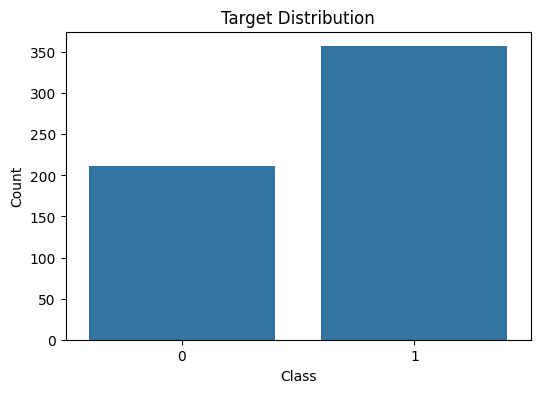

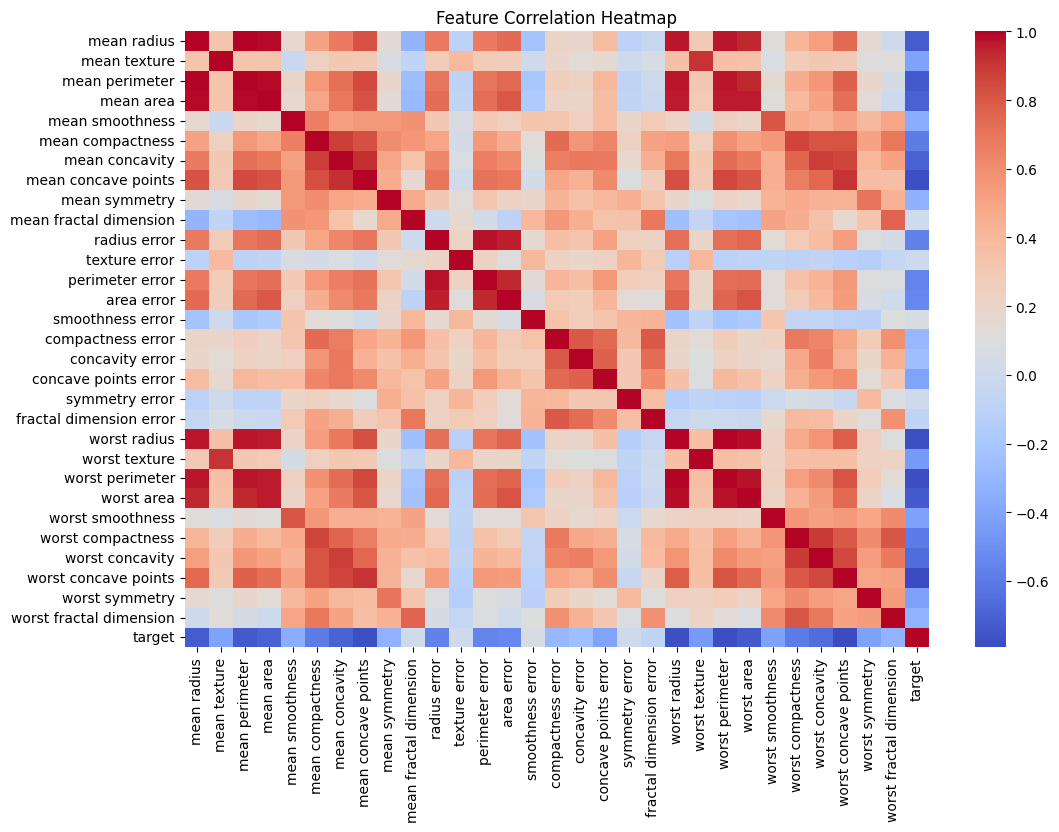


Features Shape : (569, 30)
Target Shape   : (569,)

Training Samples : 455
Testing Samples  : 114

Feature Scaling Completed Successfully

Logistic Regression Model Trained Successfully


MODEL EVALUATION
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
ROC-AUC   : 0.9954

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



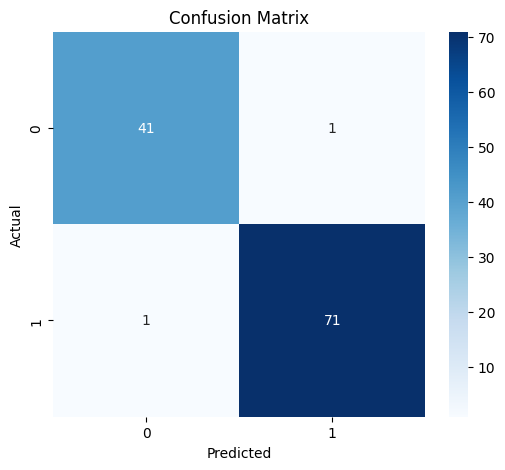

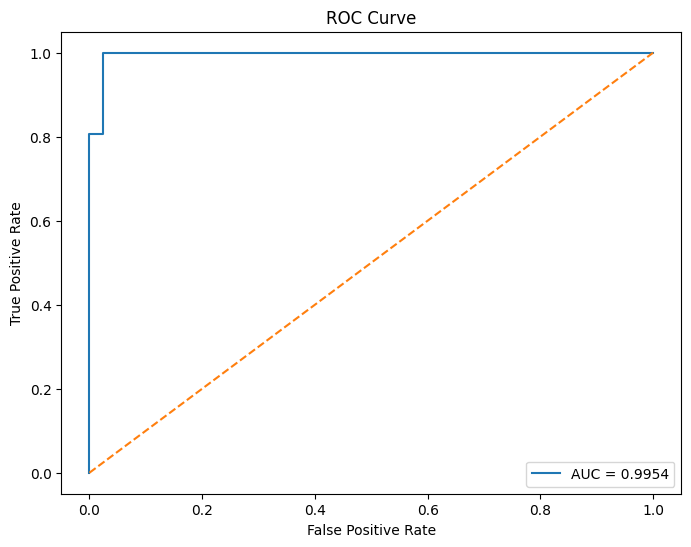

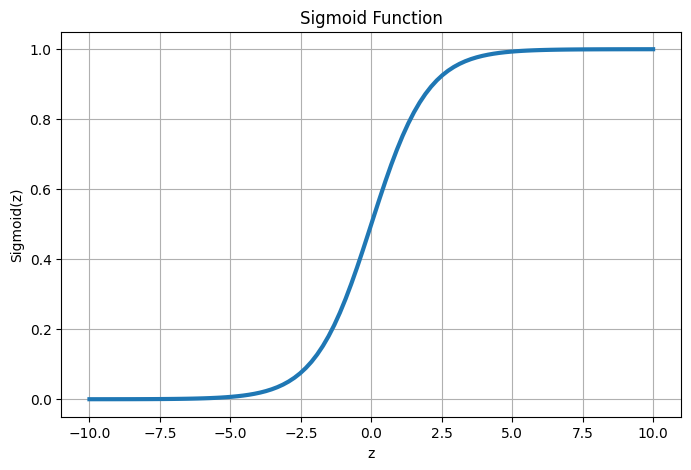


Sigmoid Function
σ(z) = 1 / (1 + e^(-z))


THRESHOLD TUNING
Default Threshold : 0.50
Custom Threshold  : 0.60

Precision : 0.9855
Recall    : 0.9444

Top 10 Important Features


,Feature,Coefficient
5,mean compactness,0.648342
15,compactness error,0.647227
19,fractal dimension error,0.437894
18,symmetry error,0.360492
11,texture error,0.248823
9,mean fractal dimension,0.199732
16,concavity error,0.160563
25,worst compactness,0.055514
14,smoothness error,-0.160276
8,mean symmetry,-0.167233




TASK 4 : LOGISTIC REGRESSION COMPLETED
Dataset Used      : Breast Cancer Wisconsin Dataset
Records           : 569
Features          : 30

Evaluation Metrics
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
ROC-AUC   : 0.9954

Operations Performed
✓ Data Loading
✓ Data Exploration
✓ Feature Scaling
✓ Train-Test Split
✓ Logistic Regression Training
✓ Prediction
✓ Confusion Matrix
✓ Precision Analysis
✓ Recall Analysis
✓ ROC-AUC Evaluation
✓ Sigmoid Function Visualization
✓ Threshold Tuning

Model Successfully Built and Evaluated


In [1]:
# ============================================================
# TASK 4 : CLASSIFICATION WITH LOGISTIC REGRESSION
# AI & ML INTERNSHIP
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)

# ============================================================
# DATA LOADING
# ============================================================

print("="*70)
print("LOADING BREAST CANCER DATASET")
print("="*70)

cancer = load_breast_cancer()

df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

df["target"] = cancer.target

print("\nDataset Shape :", df.shape)

print("\nTarget Classes")
print("0 = Malignant")
print("1 = Benign")

print("\nFirst Five Records")
display(df.head())

# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================

print("\n")
print("="*70)
print("DATASET INFORMATION")
print("="*70)

print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ============================================================
# TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop("target", axis=1)

y = df["target"]

print("\nFeatures Shape :", X.shape)
print("Target Shape   :", y.shape)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed Successfully")

# ============================================================
# LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

print("\nLogistic Regression Model Trained Successfully")

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:,1]

# ============================================================
# MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("\n")
print("="*70)
print("MODEL EVALUATION")
print("="*70)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred
))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# ============================================================
# SIGMOID FUNCTION
# ============================================================

x = np.linspace(
    -10,
    10,
    100
)

sigmoid = 1 / (
    1 + np.exp(-x)
)

plt.figure(figsize=(8,5))

plt.plot(
    x,
    sigmoid,
    linewidth=3
)

plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.grid(True)

plt.show()

print("\nSigmoid Function")
print("σ(z) = 1 / (1 + e^(-z))")

# ============================================================
# THRESHOLD TUNING
# ============================================================

threshold = 0.60

y_pred_custom = (
    y_prob >= threshold
).astype(int)

precision_custom = precision_score(
    y_test,
    y_pred_custom
)

recall_custom = recall_score(
    y_test,
    y_pred_custom
)

print("\n")
print("="*70)
print("THRESHOLD TUNING")
print("="*70)

print("Default Threshold : 0.50")
print("Custom Threshold  : 0.60")

print(f"\nPrecision : {precision_custom:.4f}")
print(f"Recall    : {recall_custom:.4f}")

# ============================================================
# MODEL COEFFICIENTS
# ============================================================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nTop 10 Important Features")

display(
    coef_df.head(10)
)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*70)
print("TASK 4 : LOGISTIC REGRESSION COMPLETED")
print("="*70)

print(f"Dataset Used      : Breast Cancer Wisconsin Dataset")
print(f"Records           : {df.shape[0]}")
print(f"Features          : {df.shape[1]-1}")

print("\nEvaluation Metrics")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nOperations Performed")

print("✓ Data Loading")
print("✓ Data Exploration")
print("✓ Feature Scaling")
print("✓ Train-Test Split")
print("✓ Logistic Regression Training")
print("✓ Prediction")
print("✓ Confusion Matrix")
print("✓ Precision Analysis")
print("✓ Recall Analysis")
print("✓ ROC-AUC Evaluation")
print("✓ Sigmoid Function Visualization")
print("✓ Threshold Tuning")

print("\nModel Successfully Built and Evaluated")

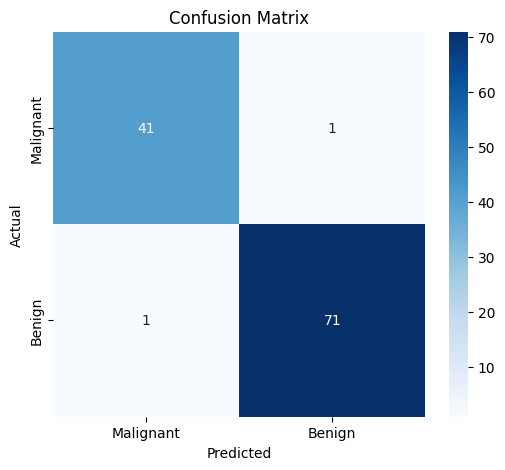

In [2]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant','Benign'],
    yticklabels=['Malignant','Benign']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

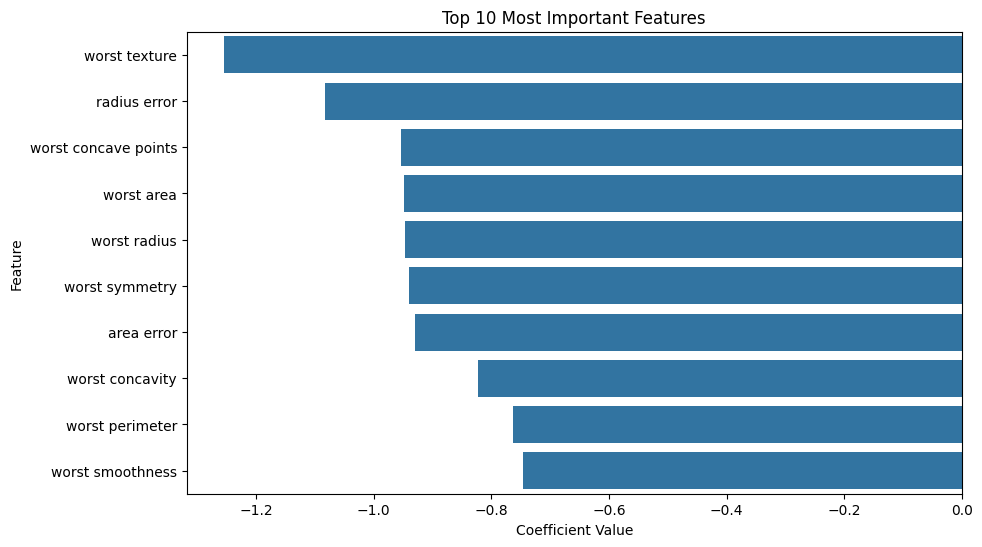

In [3]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df["Absolute"] = abs(coef_df["Coefficient"])

top_features = coef_df.sort_values(
    by="Absolute",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

In [4]:
print("\n" + "="*70)
print("MODEL INSIGHTS")
print("="*70)

print("""
1. Logistic Regression achieved excellent classification performance.

2. ROC-AUC score close to 1 indicates strong class separation.

3. Precision and Recall are well balanced, reducing both
   false positives and false negatives.

4. The model can effectively distinguish between
   malignant and benign tumors.

5. Feature coefficient analysis shows which medical
   measurements contribute most to predictions.
""")


MODEL INSIGHTS

1. Logistic Regression achieved excellent classification performance.

2. ROC-AUC score close to 1 indicates strong class separation.

3. Precision and Recall are well balanced, reducing both
   false positives and false negatives.

4. The model can effectively distinguish between
   malignant and benign tumors.

5. Feature coefficient analysis shows which medical
   measurements contribute most to predictions.



In [ ]:
print("\n" + "="*70)
print("TASK 4 : LOGISTIC REGRESSION COMPLETED")
print("="*70)

print(f"""
Dataset Used      : Breast Cancer Wisconsin Dataset
Records           : {df.shape[0]}
Features          : {X.shape[1]}

Evaluation Metrics

Accuracy  : {accuracy:.4f}
Precision : {precision:.4f}
Recall    : {recall:.4f}
ROC-AUC   : {roc_auc:.4f}

Operations Performed

✓ Data Loading
✓ Data Exploration
✓ Missing Value Analysis
✓ Feature Correlation Analysis
✓ Feature Scaling
✓ Train-Test Split
✓ Logistic Regression Training
✓ Prediction
✓ Confusion Matrix
✓ Classification Report
✓ ROC Curve Analysis
✓ Sigmoid Function Visualization
✓ Threshold Tuning
✓ Feature Importance Analysis

Model Successfully Built and Evaluated
""")

In [5]:
print("\n" + "="*70)
print("TASK 4 : LOGISTIC REGRESSION COMPLETED")
print("="*70)

print(f"""
Dataset Used      : Breast Cancer Wisconsin Dataset
Records           : {df.shape[0]}
Features          : {X.shape[1]}

Evaluation Metrics

Accuracy  : {accuracy:.4f}
Precision : {precision:.4f}
Recall    : {recall:.4f}
ROC-AUC   : {roc_auc:.4f}

Operations Performed

✓ Data Loading
✓ Data Exploration
✓ Missing Value Analysis
✓ Feature Correlation Analysis
✓ Feature Scaling
✓ Train-Test Split
✓ Logistic Regression Training
✓ Prediction
✓ Confusion Matrix
✓ Classification Report
✓ ROC Curve Analysis
✓ Sigmoid Function Visualization
✓ Threshold Tuning
✓ Feature Importance Analysis

Model Successfully Built and Evaluated
""")


TASK 4 : LOGISTIC REGRESSION COMPLETED

Dataset Used      : Breast Cancer Wisconsin Dataset
Records           : 569
Features          : 30

Evaluation Metrics

Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
ROC-AUC   : 0.9954

Operations Performed

✓ Data Loading
✓ Data Exploration
✓ Missing Value Analysis
✓ Feature Correlation Analysis
✓ Feature Scaling
✓ Train-Test Split
✓ Logistic Regression Training
✓ Prediction
✓ Confusion Matrix
✓ Classification Report
✓ ROC Curve Analysis
✓ Sigmoid Function Visualization
✓ Threshold Tuning
✓ Feature Importance Analysis

Model Successfully Built and Evaluated

